<a href="https://colab.research.google.com/github/UlaStats/MSc-project-pipe-burst-prediction/blob/main/MSc_project_data_pre_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Import

In [1]:
# upload into working space
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# import data

import pandas as pd

assets = pd.read_csv("/content/drive/MyDrive/MSc project/Assets.csv", encoding='latin1')
bursts = pd.read_csv("/content/drive/MyDrive/MSc project/burst_data.csv", encoding='latin1')
soil = pd.read_csv("/content/drive/MyDrive/MSc project/soil-pipe-matched.csv", encoding ='latin1')

/tmp/ipykernel_7100/3375540221.py:5: DtypeWarning: Columns (22,23,28) have mixed types. Specify dtype option on import or set low_memory=False.
  assets = pd.read_csv("/content/drive/MyDrive/MSc project/Assets.csv", encoding='latin1')


# Data Cleaning

In [3]:
# assets cleaning

assets_cleaned = assets[assets["Type"] == "Distribution"] # only keeping distribution mains

assets_cleaned = assets_cleaned[pd.notnull(assets_cleaned["ARM_DIAMETER"])] # deletes records with missing diameter

assets_cleaned = assets_cleaned[(assets_cleaned["Operational.Status"] != "Abandoned")] # deletes abandoned assets

assets_cleaned = assets_cleaned[(assets_cleaned["Operational.Status"] != "Removed")] # deletes removed assets

assets_cleaned = assets_cleaned[["Asset.ID", "ARM_MATERIAL", "ARM_DIAMETER", "ARM_LENGTH", "ARM_AGE", "ARM_LINING"]] # selecting attributes

assets_cleaned = assets_cleaned.rename(columns = {"ARM_MATERIAL":"Material",
                                                        "ARM_DIAMETER": "Diameter",
                                                        "ARM_LENGTH": "Length",
                                                        "ARM_AGE": "Age",
                                                        "ARM_LINING": "Lining"}) # renaming columns

<Axes: title={'center': 'No. of assets by material type'}, xlabel='Material', ylabel='No. of assets'>

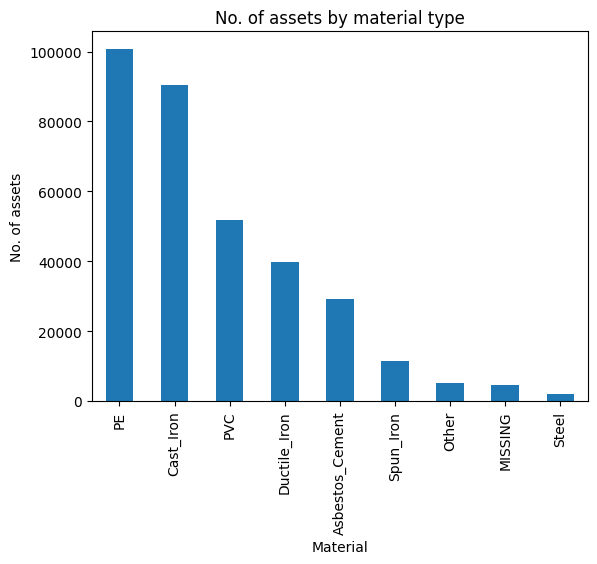

In [ ]:
# plotting

assets_attributes["Material"].value_counts().plot(kind = "bar",
                                                  ylabel = "No. of assets",
                                                  title = "No. of assets by material type")

In [4]:
# bursts cleaning

bursts_cleaned = bursts[["Asset.ID", "Raised.Date"]]

bursts_cleaned["Raised.Date"] = pd.to_datetime(bursts_cleaned["Raised.Date"], dayfirst=True) # transofrms burst date to date format

/tmp/ipykernel_7100/17490745.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bursts_cleaned["Raised.Date"] = pd.to_datetime(bursts_cleaned["Raised.Date"], dayfirst=True) # transofrms burst date to date format


In [5]:
# soil cleaning

soil = soil[["Asset.ID", "Soil"]]

# Data manipulation

In [6]:
# merging assets, bursts and soil together

assets_bursts = pd.merge(assets_cleaned, bursts_cleaned, how = "left", on = "Asset.ID")

assets_bursts = assets_bursts[pd.notnull(assets_bursts["Raised.Date"])] # removing assets without bursts

assets_bursts_soil = pd.merge(assets_bursts, soil, how = "left", on = "Asset.ID")

assets_bursts_soil = assets_bursts_soil[pd.notnull(assets_bursts_soil["Soil"])] # removing assets without soil information

In [7]:
# identify assets with 2 or more bursts

counts = bursts["Asset.ID"].value_counts()
frequent_bursters = counts[counts >= 2].index



In [8]:
# filter merged data for assets with 2 or more bursts

assets_bursts_soil_frequent = assets_bursts_soil[assets_bursts_soil["Asset.ID"].isin(frequent_bursters)]

<Axes: title={'center': 'No. of assets with >= 2 bursts'}, xlabel='Material', ylabel='No. of assets'>

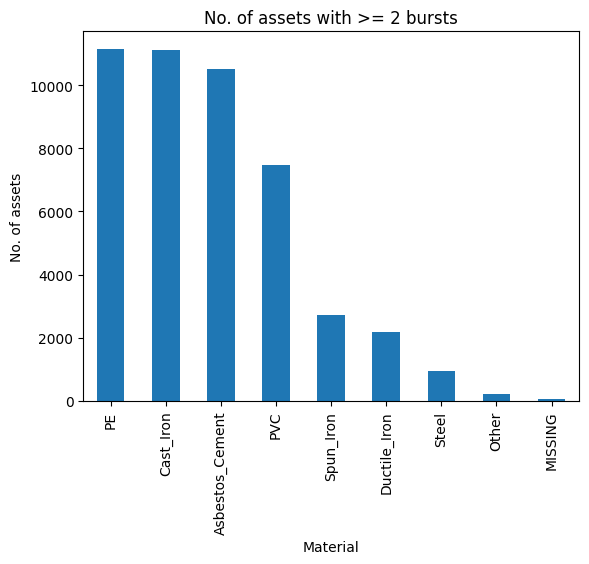

In [21]:
# examine material distribution of assets with 2 or more bursts

assets_bursts_soil_frequent["Material"].value_counts().plot(kind = "bar",
                                                                                                       ylabel = "No. of assets",
                                                                                                       title = "No. of assets with >= 2 bursts")

In [28]:
# calculate the no. of previous failures for assets with 2 or more bursts

previous_bursts = assets_bursts_soil_frequent['Asset.ID'].value_counts() - 1 # one substracted as that corresponds to future burst


TypeError: Series.rename() got an unexpected keyword argument 'columns'

In [9]:
# identify the latest two bursts for each asset

index = assets_bursts_soil_frequent.groupby("Asset.ID")["Raised.Date"].nlargest(2).reset_index(level = 0, drop = True).index

In [10]:
# subset data to contain only latest two bursts

assets_bursts_soil_frequent_2 = assets_bursts_soil_frequent.loc[index]

In [11]:
# sort using Asset ID and Date

assets_bursts_soil_frequent_2 = assets_bursts_soil_frequent_2.sort_values(by = ["Asset.ID", "Raised.Date"])


In [12]:
# introduce a pivot column

burst = ["First", "Second"] * 10764

assets_bursts_soil_frequent_2["Burst"] = burst

In [13]:
# pivot date column

frequent_bursts_2_tidy = assets_bursts_soil_frequent_2.pivot(values = "Raised.Date", columns = "Burst", index = "Asset.ID").reset_index()


In [57]:
# merge pivoted column with the original assets and soil data

attributes = pd.merge(frequent_bursts_2_tidy, assets_cleaned, how = "inner", on = "Asset.ID")

attributes = pd.merge(attributes, soil, on = "Asset.ID", how = "inner")


In [49]:
# merge with the no. of previous failures

attributes = pd.merge(attributes, previous_bursts, how = "inner", on = "Asset.ID")
attributes = attributes.rename(columns={"count":"previous fails"}) # change column name

In [59]:
# calculate and add time-to-break attribute

time_to_next_break = attributes["Second"] - attributes["First"]

attributes["Time-to-next-break"] = time_to_next_break



In [63]:
attributes.dtypes

,0
Asset.ID,float64
First,datetime64[ns]
Second,datetime64[ns]
Material,object
Diameter,float64
Length,float64
Age,float64
Lining,object
Soil,object
Time-to-next-break,timedelta64[ns]


In [64]:
attributes['Time-to-next-break'].astype("int64")/ (1e9 * 60 * 60 * 24) # convert to numeric data type (converted from nano seconds to days)

,Time-to-next-break
0,310.0
1,3685.0
2,3888.0
3,52.0
4,1404.0
...,...
10759,2.0
10760,0.0
10761,2.0
10762,73.0


In [ ]:
# save attributes

attributes.to_csv("/content/drive/MyDrive/MSc project/attributes.csv", encoding ='latin1', index=False)

In [60]:
attributes

,Asset.ID,First,Second,Material,Diameter,Length,Age,Lining,Soil,Time-to-next-break
0,366637.0,2021-01-01,2021-11-07,Spun_Iron,152.4,348.928198,59.0,PRESENT,Brown earths,310 days
1,366673.0,2013-04-03,2023-05-06,PVC,76.2,395.264947,52.0,NOT_PRESENT,Brown earths,3685 days
2,366727.0,2007-06-22,2018-02-12,Spun_Iron,101.6,120.534624,69.0,PRESENT,Brown earths,3888 days
3,366744.0,2021-01-15,2021-03-08,Cast_Iron,152.4,690.101258,114.0,NOT_PRESENT,Brown earths,52 days
4,366762.0,2020-01-12,2023-11-16,Cast_Iron,152.4,211.071255,59.0,PRESENT,Brown earths,1404 days
...,...,...,...,...,...,...,...,...,...,...
10759,691697930.0,2013-08-17,2013-08-19,PE,110.0,449.946682,8.0,NOT_PRESENT,Podzols,2 days
10760,691764444.0,2006-03-13,2006-03-13,PE,125.0,24.252775,9.0,NOT_PRESENT,Brown earths,0 days
10761,691764478.0,2012-10-15,2012-10-17,Ductile_Iron,200.0,90.510801,8.0,PRESENT,Brown earths,2 days
10762,691897408.0,2015-08-27,2015-11-08,PE,90.0,1216.772764,8.0,NOT_PRESENT,Podzols,73 days


# Feature engineering

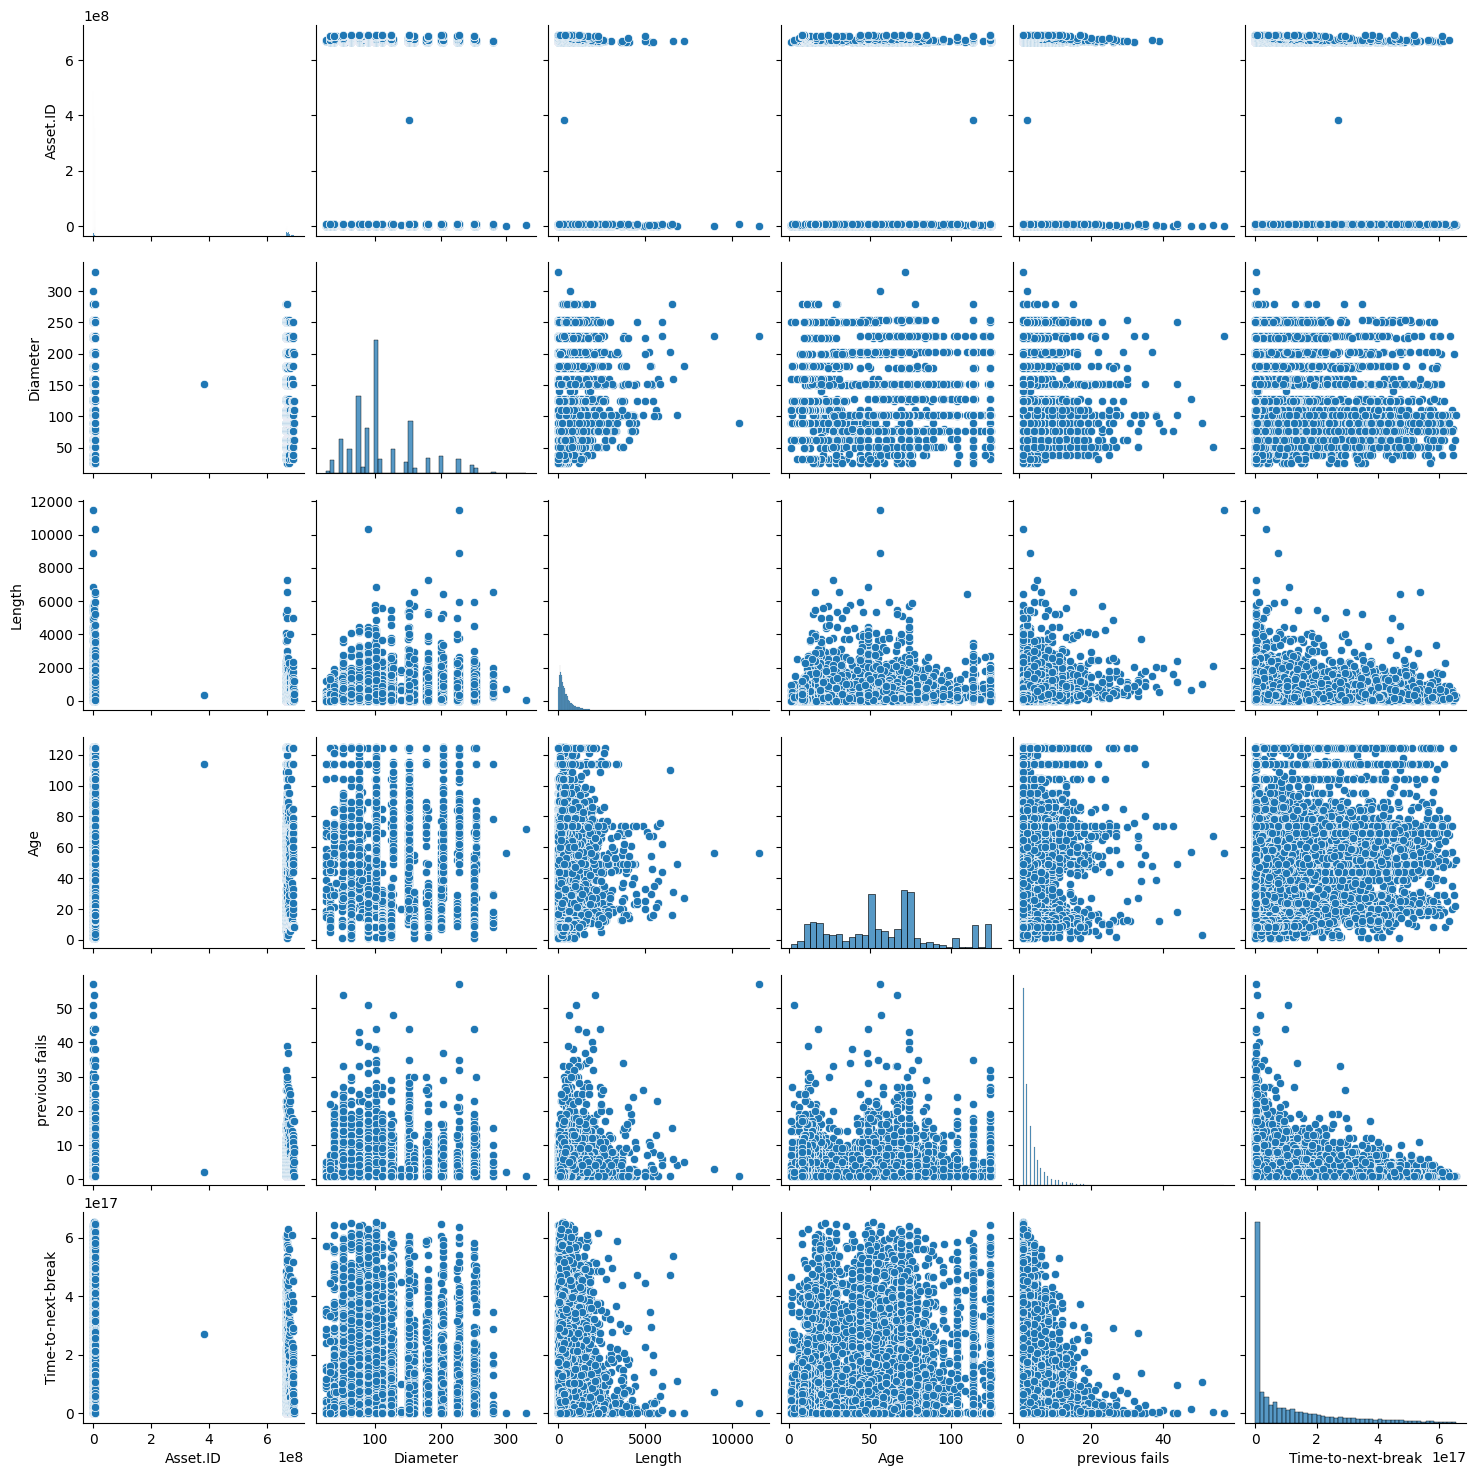

In [55]:
# examine correlations

import seaborn as sns

sns.pairplot(attributes)

In [ ]:
# test whether dis of time-to-break is different for soil type, lining and material